## Rice Leaf Disease Classification using CNN

This project builds a custom Convolutional Neural Network (CNN) to classify rice leaf diseases into four categories:
- Bacterial Blight
- Blast
- Brown Spot
- Tungro

The goal is to support early disease detection in agriculture using deep learning.

## 1. Import Libraries
Import required Python libraries for deep learning and image processing.

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

## 2. Dataset Preparation
The dataset is structured into training, validation, and testing folders.

Images are resized to 150x150 pixels.

In [ ]:
train_dir = 'dataset/train'
val_dir = 'dataset/val'
test_dir = 'dataset/test'
img_width, img_height = 150, 150
batch_size = 32

## 3. Data Preprocessing & Augmentation
Data augmentation is applied to improve model generalization and prevent overfitting.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,class_mode='categorical')

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size, class_mode='categorical')

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size, class_mode='categorical')

Found 4150 images belonging to 4 classes.
Found 889 images belonging to 4 classes.
Found 893 images belonging to 4 classes.


## 4. CNN Model Architecture
A custom Sequential CNN model is built using multiple convolutional and pooling layers, followed by fully connected layers.

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(4, activation='softmax')
])

## 5. Model Training
The model is trained for 20 epochs using Adam optimizer and categorical crossentropy loss.

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model_CNN = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size)

model.save('Custom_CNN_Model_1.h5')
model.summary()

## 6. Model Evaluation
The trained model is evaluated on unseen test data to measure accuracy and performance.

In [ ]:
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print('Test accuracy:', test_acc)

## 7. Classification Report
Precision, Recall, and F1-score are calculated to evaluate performance across all four classes.

In [ ]:
model = load_model('Custom_CNN_Model_1.h5')
test_images_dir = 'dataset/test'
test_image_files = []
for subdir, dirs, files in os.walk(test_images_dir):
  for file in files:
    test_image_files.append(os.path.join(subdir, file))

class_labels = list(train_generator.class_indices.keys())
label_to_index = {label: index for index, label in enumerate(class_labels)}

true_labels = []
predicted_labels = []

for img_path in test_image_files:
    if os.path.isfile(img_path):
        img = image.load_img(img_path, target_size=(150, 150))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array /= 255.
        prediction = model.predict(img_array)
        predicted_class_index = np.argmax(prediction)
        true_label = os.path.basename(os.path.dirname(img_path))
        true_class_index = label_to_index.get(true_label, -1)

        if true_class_index != -1:
            true_labels.append(true_class_index)
            predicted_labels.append(predicted_class_index)
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

## 8. Sample Predictions
Visualization of actual vs predicted classes to interpret model performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


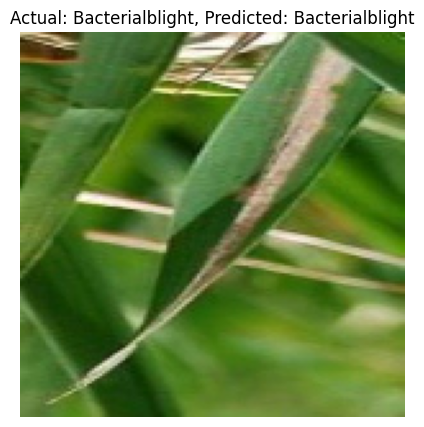

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


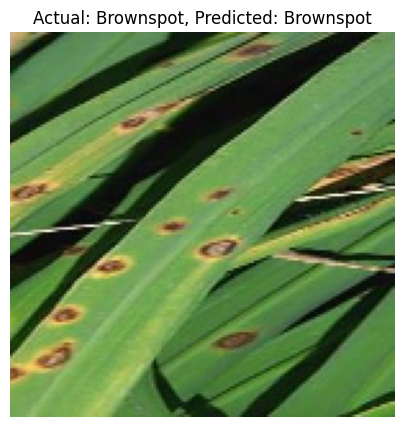

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


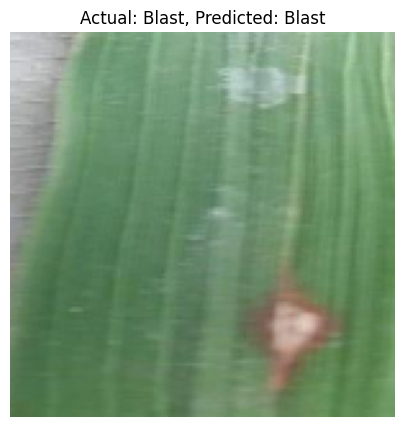

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


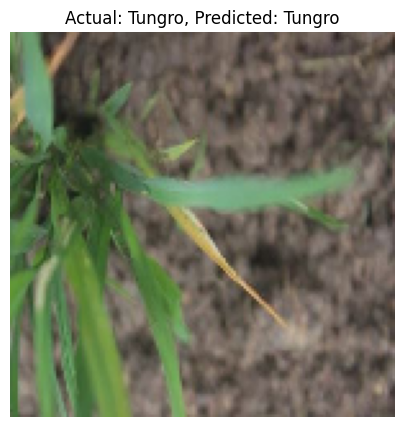

In [ ]:
test_images_dir = 'dataset/test'

class_labels = list(train_generator.class_indices.keys())
images_per_class = {}
for subdir, dirs, files in os.walk(test_images_dir):
    class_name = os.path.basename(subdir)
    if class_name in class_labels and class_name not in images_per_class:
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images_per_class[class_name] = os.path.join(subdir, file)
                break

for class_name, img_path in images_per_class.items():
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.

    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)
    predicted_class = class_labels[predicted_class_index]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'Actual: {class_name}, Predicted: {predicted_class}')
    plt.axis('off')
    plt.show()